<a href="https://colab.research.google.com/github/Matteo-Raschi/Open_Data_Workshop_GW_2026/blob/main/Challenge1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
! pip install -q lalsuite gwpy pycbc
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge1.gwf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 73.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

/usr/local/lib/python3.12/dist-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


Sampling rate: 4096.0 Hz
Duration: 128.0 s


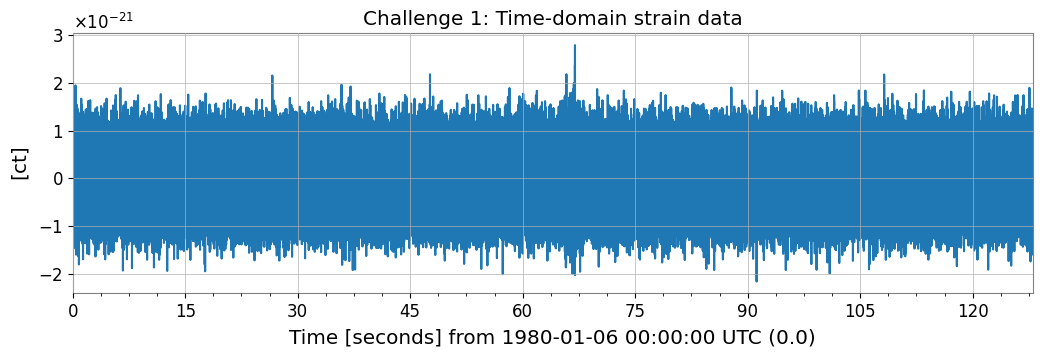

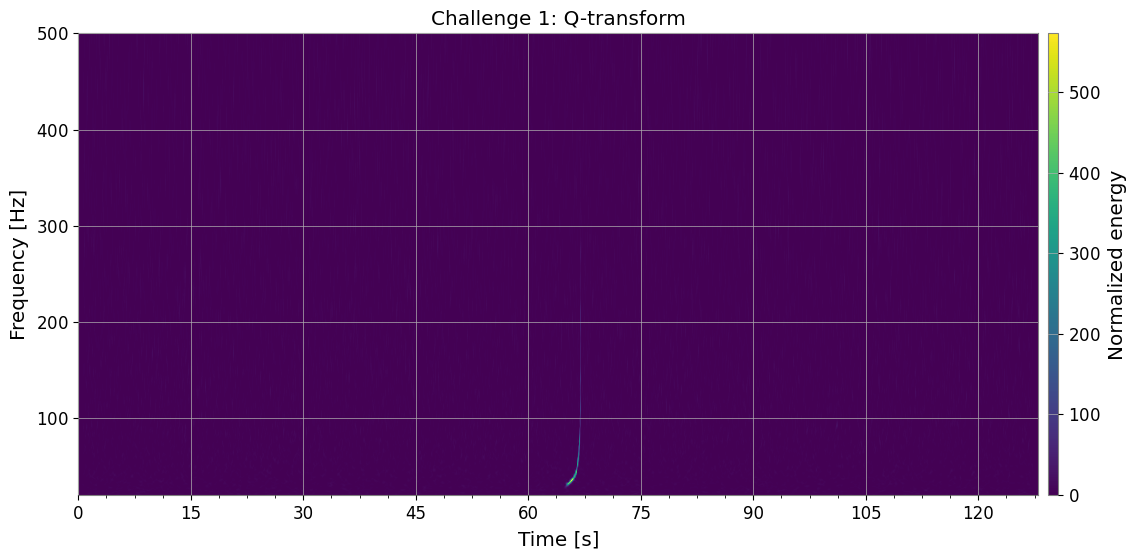


FINAL SOLUTION:
The time of the merger is 66.97 seconds from the start of the segment.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

# 1. Load the data into memory
data_file = 'challenge1.gwf'
channel = 'H1:CHALLENGE1'
strain = TimeSeries.read(data_file, channel=channel)

# Print Sampling Rate and Duration
print(f"Sampling rate: {strain.sample_rate}")
print(f"Duration: {strain.duration}")

# 2. Plot the data in the time-domain
plot = strain.plot()
plt.title("Challenge 1: Time-domain strain data")
plt.show()

# 3. Plot a Q-transform of the data to identify the signal
qspecgram = strain.q_transform(frange=(20, 500))
plot = qspecgram.plot()
ax = plot.gca()
ax.set_title("Challenge 1: Q-transform")
ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel("Time [s]")
ax.colorbar(label="Normalized energy")
plt.show()

# 4. Find the exact time of the merger
# Since this is white Gaussian noise, the merger corresponds to the peak amplitude.
abs_strain = np.abs(strain.value)
peak_idx = np.argmax(abs_strain)
peak_time = strain.times.value[peak_idx]
start_time = strain.t0.value

merger_time_from_start = peak_time - start_time
print(f"\nFINAL SOLUTION:")
print(f"The time of the merger is {merger_time_from_start:.2f} seconds from the start of the segment.")
